# Exploring the ImplicitPersona Dataset

This notebook downloads and explores the `bowen-upenn/ImplicitPersona` dataset to understand:
- What data it provides
- How it tests various aspects of persona/implicit information
- The structure of rows and columns
- What it evaluates and how


In [15]:
# Install required packages if needed
%pip install datasets pandas numpy matplotlib seaborn -q


Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import json
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Any, List

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Download the Dataset


In [17]:
# Load the ImplicitPersona dataset from HuggingFace
print("Downloading ImplicitPersona dataset...")
dataset = load_dataset("bowen-upenn/ImplicitPersona")
print(f"\nDataset loaded successfully!")
print(f"Available splits: {list(dataset.keys())}")



Dataset loaded successfully!
Available splits: ['benchmark_multimodal', 'train_multimodal', 'val_multimodal', 'benchmark_text', 'train_text', 'val_text']


## 2. Explore Dataset Structure


In [18]:
# Examine the structure of each split
for split_name, split_data in dataset.items():
    print(f"\n{'='*60}")
    print(f"Split: {split_name}")
    print(f"Number of examples: {len(split_data)}")
    print(f"\nFeatures/Columns: {list(split_data.features.keys())}")
    print(f"\nFeature details:")
    for feature_name, feature_type in split_data.features.items():
        print(f"  - {feature_name}: {feature_type}")



Split: benchmark_multimodal
Number of examples: 5000

Features/Columns: ['persona_id', 'chat_history_32k_link', 'chat_history_128k_link', 'raw_persona_file', 'short_persona', 'expanded_persona', 'user_query', 'correct_answer', 'incorrect_answers', 'topic_query', 'preference', 'topic_preference', 'conversation_scenario', 'pref_type', 'related_conversation_snippet', 'who', 'updated', 'prev_pref', 'sensitive_info', 'total_tokens_in_chat_history_32k', 'total_tokens_in_chat_history_128k', 'distance_from_related_snippet_to_query_32k', 'distance_from_related_snippet_to_query_128k', 'num_persona_relevant_tokens_32k', 'num_persona_irrelevant_tokens_32k', 'num_persona_relevant_tokens_128k', 'num_persona_irrelevant_tokens_128k']

Feature details:
  - persona_id: Value('int64')
  - chat_history_32k_link: Value('string')
  - chat_history_128k_link: Value('string')
  - raw_persona_file: Value('string')
  - short_persona: Value('string')
  - expanded_persona: Value('string')
  - user_query: Value('s

In [19]:
# Look at a few example entries from each split
for split_name, split_data in dataset.items():
    print(f"\n{'='*60}")
    print(f"Sample entries from '{split_name}' split:")
    print(f"{'='*60}")
    
    # Show first 2 examples
    for i in range(min(2, len(split_data))):
        example = split_data[i]
        print(f"\n--- Example {i+1} ---")
        for key, value in example.items():
            if isinstance(value, str) and len(value) > 200:
                print(f"{key}: {value[:200]}...")
            elif isinstance(value, list) and len(value) > 5:
                print(f"{key}: {value[:5]}... (total: {len(value)} items)")
            else:
                print(f"{key}: {value}")



Sample entries from 'benchmark_multimodal' split:

--- Example 1 ---
persona_id: 521
chat_history_32k_link: data/chat_history_multimodal_32k/chat_history_250913_163134_persona521.json
chat_history_128k_link: data/chat_history_multimodal_128k/chat_history_250913_163556_persona521.json
raw_persona_file: data/raw_data/raw_data_250819_225921_persona521.json
short_persona: {'persona': "A liberal Democrat from Kansas, slightly skeptical about Republican candidates, but also respects politicians' personal lives."}
expanded_persona: {
  "short_persona": {
    "persona": "A liberal Democrat from Kansas, slightly skeptical about Republican candidates, but also respects politicians' personal lives."
  },
  "name": "Daniel Robert Whi...
user_query: {'role': 'user', 'content': 'What are some calming morning routines that can help set a positive tone for the rest of the day?'}
correct_answer: Since you already practice yoga and meditation daily, you might enjoy starting your mornings with a gentle 

## 3. Convert to Pandas DataFrame for Analysis


In [20]:
# Convert each split to a pandas DataFrame
dataframes = {}
for split_name, split_data in dataset.items():
    df = split_data.to_pandas()
    dataframes[split_name] = df
    print(f"\n{split_name} DataFrame shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")



benchmark_multimodal DataFrame shape: (5000, 27)
Columns: ['persona_id', 'chat_history_32k_link', 'chat_history_128k_link', 'raw_persona_file', 'short_persona', 'expanded_persona', 'user_query', 'correct_answer', 'incorrect_answers', 'topic_query', 'preference', 'topic_preference', 'conversation_scenario', 'pref_type', 'related_conversation_snippet', 'who', 'updated', 'prev_pref', 'sensitive_info', 'total_tokens_in_chat_history_32k', 'total_tokens_in_chat_history_128k', 'distance_from_related_snippet_to_query_32k', 'distance_from_related_snippet_to_query_128k', 'num_persona_relevant_tokens_32k', 'num_persona_irrelevant_tokens_32k', 'num_persona_relevant_tokens_128k', 'num_persona_irrelevant_tokens_128k']

train_multimodal DataFrame shape: (18990, 27)
Columns: ['persona_id', 'chat_history_32k_link', 'chat_history_128k_link', 'raw_persona_file', 'short_persona', 'expanded_persona', 'user_query', 'correct_answer', 'incorrect_answers', 'topic_query', 'preference', 'topic_preference', 'con

## 4. Detailed Column Analysis


In [21]:
# Analyze each column in detail
for split_name, df in dataframes.items():
    print(f"\n{'='*80}")
    print(f"Detailed Analysis: {split_name} Split")
    print(f"{'='*80}")
    
    print(f"\nBasic Info:")
    print(df.info())
    
    print(f"\n\nFirst few rows:")
    display(df.head())
    
    print(f"\n\nColumn Statistics:")
    for col in df.columns:
        print(f"\n--- Column: {col} ---")
        if df[col].dtype in ['int64', 'float64']:
            print(df[col].describe())
        elif df[col].dtype == 'object':
            # Check if it's a string column
            if df[col].apply(lambda x: isinstance(x, str)).all():
                print(f"Type: String")
                print(f"Unique values: {df[col].nunique()}")
                print(f"Sample values:")
                for val in df[col].head(3).values:
                    if isinstance(val, str):
                        print(f"  - {val[:100]}..." if len(val) > 100 else f"  - {val}")
            # Check if it's a list column
            elif df[col].apply(lambda x: isinstance(x, list)).any():
                print(f"Type: List")
                lengths = df[col].apply(lambda x: len(x) if isinstance(x, list) else 0)
                print(f"Average length: {lengths.mean():.2f}")
                print(f"Min length: {lengths.min()}")
                print(f"Max length: {lengths.max()}")
                print(f"Sample first item: {df[col].iloc[0]}")
            else:
                print(f"Type: Mixed/Object")
                print(f"Unique values: {df[col].nunique()}")
                print(f"Sample values: {df[col].head(3).tolist()}")



Detailed Analysis: benchmark_multimodal Split

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   persona_id                                   5000 non-null   int64 
 1   chat_history_32k_link                        5000 non-null   object
 2   chat_history_128k_link                       5000 non-null   object
 3   raw_persona_file                             5000 non-null   object
 4   short_persona                                5000 non-null   object
 5   expanded_persona                             5000 non-null   object
 6   user_query                                   5000 non-null   object
 7   correct_answer                               5000 non-null   object
 8   incorrect_answers                            5000 non-null   object
 9   topic_query              

,persona_id,chat_history_32k_link,chat_history_128k_link,raw_persona_file,short_persona,expanded_persona,user_query,correct_answer,incorrect_answers,topic_query,...,prev_pref,sensitive_info,total_tokens_in_chat_history_32k,total_tokens_in_chat_history_128k,distance_from_related_snippet_to_query_32k,distance_from_related_snippet_to_query_128k,num_persona_relevant_tokens_32k,num_persona_irrelevant_tokens_32k,num_persona_relevant_tokens_128k,num_persona_irrelevant_tokens_128k
0,521,data/chat_history_multimodal_32k/chat_history_...,data/chat_history_multimodal_128k/chat_history...,data/raw_data/raw_data_250819_225921_persona52...,"{'persona': ""A liberal Democrat from Kansas, s...","{\n ""short_persona"": {\n ""persona"": ""A lib...","{'role': 'user', 'content': 'What are some cal...",Since you already practice yoga and meditation...,"[""Since you enjoy experimenting with new veget...",Health,...,None,False,31842,104178,28768,34748,31842,0,45421,58757
1,521,data/chat_history_multimodal_32k/chat_history_...,data/chat_history_multimodal_128k/chat_history...,data/raw_data/raw_data_250819_225921_persona52...,"{'persona': ""A liberal Democrat from Kansas, s...","{\n ""short_persona"": {\n ""persona"": ""A lib...","{'role': 'user', 'content': 'How can I stay gr...",When a student shares something deeply troubli...,"[""When you feel emotionally heavy, it can help...",Communication,...,None,False,31842,104178,27632,91785,31842,0,45421,58757
2,521,data/chat_history_multimodal_32k/chat_history_...,data/chat_history_multimodal_128k/chat_history...,data/raw_data/raw_data_250819_225921_persona52...,"{'persona': ""A liberal Democrat from Kansas, s...","{\n ""short_persona"": {\n ""persona"": ""A lib...","{'role': 'user', 'content': 'How can I manage ...","After a tense confrontation, it can help to st...","[""After dealing with that aggressive parent du...",Health,...,None,False,31842,104178,29128,31366,31842,0,45421,58757
3,521,data/chat_history_multimodal_32k/chat_history_...,data/chat_history_multimodal_128k/chat_history...,data/raw_data/raw_data_250819_225921_persona52...,"{'persona': ""A liberal Democrat from Kansas, s...","{\n ""short_persona"": {\n ""persona"": ""A lib...","{'role': 'user', 'content': ""I'm planning a tr...",Since you’re passionate about surfing when you...,"[""Since you’re fascinated by marine wildlife, ...",Travel,...,None,False,31842,104178,11526,93283,31842,0,45421,58757
4,521,data/chat_history_multimodal_32k/chat_history_...,data/chat_history_multimodal_128k/chat_history...,data/raw_data/raw_data_250819_225921_persona52...,"{'persona': ""A liberal Democrat from Kansas, s...","{\n ""short_persona"": {\n ""persona"": ""A lib...","{'role': 'user', 'content': 'What are some cre...",Since you already enjoy baking fresh bread at ...,"[""Since you enjoy photography, you might try a...",Food,...,None,False,31842,104178,18210,73443,31842,0,45421,58757




Column Statistics:

--- Column: persona_id ---
count    5000.000000
mean      517.737200
std       292.649751
min        10.000000
25%       260.000000
50%       543.000000
75%       761.000000
max       998.000000
Name: persona_id, dtype: float64

--- Column: chat_history_32k_link ---
Type: String
Unique values: 195
Sample values:
  - data/chat_history_multimodal_32k/chat_history_250913_163134_persona521.json
  - data/chat_history_multimodal_32k/chat_history_250913_163134_persona521.json
  - data/chat_history_multimodal_32k/chat_history_250913_163134_persona521.json

--- Column: chat_history_128k_link ---
Type: String
Unique values: 195
Sample values:
  - data/chat_history_multimodal_128k/chat_history_250913_163556_persona521.json
  - data/chat_history_multimodal_128k/chat_history_250913_163556_persona521.json
  - data/chat_history_multimodal_128k/chat_history_250913_163556_persona521.json

--- Column: raw_persona_file ---
Type: String
Unique values: 195
Sample values:
  - data/raw_

,persona_id,chat_history_32k_link,chat_history_128k_link,raw_persona_file,short_persona,expanded_persona,user_query,correct_answer,incorrect_answers,topic_query,...,prev_pref,sensitive_info,total_tokens_in_chat_history_32k,total_tokens_in_chat_history_128k,distance_from_related_snippet_to_query_32k,distance_from_related_snippet_to_query_128k,num_persona_relevant_tokens_32k,num_persona_irrelevant_tokens_32k,num_persona_relevant_tokens_128k,num_persona_irrelevant_tokens_128k
0,115,data/chat_history_multimodal_32k/chat_history_...,data/chat_history_multimodal_128k/chat_history...,data/raw_data/raw_data_250815_163935_persona11...,A research institute director who offers the s...,"{\n ""short_persona"": ""A research institute di...","{'role': 'user', 'content': 'What are some uni...",You could volunteer to help coordinate the tra...,"[""You could volunteer to help coordinate cooki...",Community,...,None,False,32164,93763,11922,81486,32164,0,47883,45710
1,968,data/chat_history_multimodal_32k/chat_history_...,data/chat_history_multimodal_128k/chat_history...,data/raw_data/raw_data_250826_131038_persona96...,A data-driven sports analyst who is interested...,"{\n ""short_persona"": ""A data-driven sports an...","{'role': 'user', 'content': 'What are some goo...",To mitigate lower back strain during extended ...,"[""To reduce frequent eye strain from prolonged...",health,...,None,False,31510,123527,16247,118562,31510,0,38175,85352
2,403,data/chat_history_multimodal_32k/chat_history_...,data/chat_history_multimodal_128k/chat_history...,data/raw_data/raw_data_250818_011555_persona40...,A trailblazing novelist noted for her complex ...,"{\n ""short_persona"": ""A trailblazing novelist...","{'role': 'user', 'content': 'I’m planning to r...",If you like travel gear with an artisanal or h...,"[""Since you gravitate toward sleek, modern tec...",Travel,...,"Prefers sleek, modern tech gadgets over handcr...",False,31964,125000,24935,106896,31964,0,32645,92355
3,90,data/chat_history_multimodal_32k/chat_history_...,data/chat_history_multimodal_128k/chat_history...,data/raw_data/raw_data_250815_163935_persona90...,A traditional toy store owner promoting handcr...,"{\n ""short_persona"": ""A traditional toy store...","{'role': 'user', 'content': ""Hi there, I’m in ...","To complete your application, you should gathe...","[""To complete your application, you should gat...",education,...,None,True,32085,116705,0,0,32085,0,42719,73901
4,146,data/chat_history_multimodal_32k/chat_history_...,data/chat_history_multimodal_128k/chat_history...,data/raw_data/raw_data_250815_163935_persona14...,A non-tech savvy golf enthusiast,"{\n ""short_persona"": ""A non-tech savvy golf e...","{'role': 'user', 'content': 'What are some of ...","If you enjoy sports venues, you might like Fen...","[""Since you follow American baseball more than...",Sports,...,Follows American baseball more than soccer,False,31713,119870,16568,69656,31713,0,33185,86685




Column Statistics:

--- Column: persona_id ---
count    18990.000000
mean       499.336493
std        292.865773
min          0.000000
25%        226.000000
50%        504.000000
75%        757.000000
max        999.000000
Name: persona_id, dtype: float64

--- Column: chat_history_32k_link ---
Type: String
Unique values: 805
Sample values:
  - data/chat_history_multimodal_32k/chat_history_250913_163134_persona115.json
  - data/chat_history_multimodal_32k/chat_history_250913_163134_persona968.json
  - data/chat_history_multimodal_32k/chat_history_250913_163134_persona403.json

--- Column: chat_history_128k_link ---
Type: String
Unique values: 805
Sample values:
  - data/chat_history_multimodal_128k/chat_history_250913_163556_persona115.json
  - data/chat_history_multimodal_128k/chat_history_250913_163556_persona968.json
  - data/chat_history_multimodal_128k/chat_history_250913_163556_persona403.json

--- Column: raw_persona_file ---
Type: String
Unique values: 805
Sample values:
  - d

...



Column Statistics:

--- Column: persona_id ---
count    5000.000000
mean      513.648200
std       291.611292
min        10.000000
25%       259.000000
50%       542.000000
75%       753.000000
max       998.000000
Name: persona_id, dtype: float64

--- Column: chat_history_32k_link ---
Type: String
Unique values: 200
Sample values:
  - data/chat_history_32k/chat_history_250913_163134_persona521.json
  - data/chat_history_32k/chat_history_250913_163134_persona521.json
  - data/chat_history_32k/chat_history_250913_163134_persona521.json

--- Column: chat_history_128k_link ---
Type: String
Unique values: 200
Sample values:
  - data/chat_history_128k/chat_history_250913_163556_persona521.json
  - data/chat_history_128k/chat_history_250913_163556_persona521.json
  - data/chat_history_128k/chat_history_250913_163556_persona521.json

--- Column: raw_persona_file ---
Type: String
Unique values: 200
Sample values:
  - data/raw_data/raw_data_250819_225921_persona521.json
  - data/raw_data/raw_

,persona_id,chat_history_32k_link,chat_history_128k_link,raw_persona_file,short_persona,expanded_persona,user_query,correct_answer,incorrect_answers,topic_query,...,prev_pref,sensitive_info,total_tokens_in_chat_history_32k,total_tokens_in_chat_history_128k,distance_from_related_snippet_to_query_32k,distance_from_related_snippet_to_query_128k,num_persona_relevant_tokens_32k,num_persona_irrelevant_tokens_32k,num_persona_relevant_tokens_128k,num_persona_irrelevant_tokens_128k
0,13,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250815_155601_persona13...,An HIV+ person who works in a modest clerical ...,"{\n ""short_persona"": ""An HIV+ person who work...","{'role': 'user', 'content': 'How can I manage ...",When those surprise costs start adding up – es...,"[""When you feel stressed about expenses – espe...",Health,...,None,False,31851,123710,20744,50070,31851,0,41902,81808
1,229,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250815_163935_persona22...,A machine learning engineer with a fascination...,"{\n ""short_persona"": ""A machine learning engi...","{'role': 'user', 'content': 'What upcoming dev...",One notable shift on the horizon is the IMO’s ...,"[""One notable shift on the horizon is the IMO’...",Maritime,...,Follows maritime industry news closely,False,31553,125125,22064,59018,31553,0,33787,91338
2,950,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250826_131038_persona95...,A disgruntled city employee who leaks sensitiv...,"{\n ""short_persona"": ""A disgruntled city empl...","{'role': 'user', 'content': 'What’s the best w...",If you usually split communication between you...,"[""Since you rely solely on your phone, you mig...",Communication,...,Relies solely on mobile for communication,False,31763,124008,19572,39176,31763,0,31763,92245
3,191,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250815_163935_persona19...,A university biology lecturer with a fascinati...,"{\n ""short_persona"": ""A university biology le...","{'role': 'user', 'content': 'How can I manage ...",It can help to treat tenure anxiety like the d...,"[""It can help to treat pre-conference jitters ...",Health,...,None,False,31999,124897,13155,99745,31999,0,36680,88217
4,911,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250825_220103_persona91...,a passionate Barnsley FC fan who follows every...,"{\n ""short_persona"": ""a passionate Barnsley F...","{'role': 'user', 'content': 'Is it okay to dri...","Aye lass, sipping chamomile or peppermint dail...","[""Aye lass, sipping chamomile or peppermint da...",health,...,None,False,31837,121820,30042,84363,31837,0,38873,82947




Column Statistics:

--- Column: persona_id ---
count    18549.000000
mean       499.844143
std        293.385804
min          0.000000
25%        226.000000
50%        505.000000
75%        757.000000
max        999.000000
Name: persona_id, dtype: float64

--- Column: chat_history_32k_link ---
Type: String
Unique values: 800
Sample values:
  - data/chat_history_32k/chat_history_250913_163134_persona13.json
  - data/chat_history_32k/chat_history_250913_163134_persona229.json
  - data/chat_history_32k/chat_history_250913_163134_persona950.json

--- Column: chat_history_128k_link ---
Type: String
Unique values: 800
Sample values:
  - data/chat_history_128k/chat_history_250913_163556_persona13.json
  - data/chat_history_128k/chat_history_250913_163556_persona229.json
  - data/chat_history_128k/chat_history_250913_163556_persona950.json

--- Column: raw_persona_file ---
Type: String
Unique values: 800
Sample values:
  - data/raw_data/raw_data_250815_155601_persona13.json
  - data/raw_data

,persona_id,chat_history_32k_link,chat_history_128k_link,raw_persona_file,short_persona,expanded_persona,user_query,correct_answer,incorrect_answers,topic_query,...,prev_pref,sensitive_info,total_tokens_in_chat_history_32k,total_tokens_in_chat_history_128k,distance_from_related_snippet_to_query_32k,distance_from_related_snippet_to_query_128k,num_persona_relevant_tokens_32k,num_persona_irrelevant_tokens_32k,num_persona_relevant_tokens_128k,num_persona_irrelevant_tokens_128k
0,988,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250826_131038_persona98...,An Englishman in his 60s who used to play hurling,"{\n ""short_persona"": ""An Englishman in his 60...","{'role': 'user', 'content': 'Can you suggest s...","You could try ‘The Daily’ for current events, ...","[""Since you enjoy your astrophysics podcasts, ...",Education,...,None,False,29261,124982,23869,39281,29261,0,29261,95721
1,782,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250820_224501_persona78...,A compliance expert who ensures that branding ...,"{\n ""short_persona"": ""A compliance expert who...","{'role': 'user', 'content': 'What are some ele...",You could elevate a simple evening look by dra...,"[""You could elevate a simple evening look by s...",Fashion,...,None,False,31978,117786,16938,31813,31978,0,43443,74343
2,730,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250820_224501_persona73...,A cannabis cultivator afraid of his investment,"{\n ""short_persona"": ""A cannabis cultivator a...","{'role': 'user', 'content': 'What are some eff...",You might look for mentors through professiona...,"[""You might look for mentors through LGBTQ+ bu...",Mentorship,...,Struggled to find LGBTQ+ friendly financial ad...,False,31764,124331,17911,101839,31764,0,32113,92218
3,243,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250815_163935_persona24...,A market researcher closely monitoring the imp...,"{\n ""short_persona"": ""A market researcher clo...","{'role': 'user', 'content': 'What are some goo...",Since your occasional migraines stem from scre...,"[""Since you’re training for a half-marathon, i...",health,...,None,False,31804,126219,24888,48377,31804,0,34990,91229
4,400,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250818_011555_persona40...,"An ardent movie buff who collects DVDs, Blus &...","{\n ""short_persona"": ""An ardent movie buff wh...","{'role': 'user', 'content': 'Where’s the best ...","To clearly see slides and the board, aim for a...","[""Since you’re mildly nearsighted and wear gla...",Study,...,Mild nearsightedness requiring corrective glasses,False,31678,122620,26512,41952,31678,0,32918,89702




Column Statistics:

--- Column: persona_id ---
count    2061.000000
mean      499.218826
std       293.954456
min         0.000000
25%       227.000000
50%       500.000000
75%       760.000000
max       999.000000
Name: persona_id, dtype: float64

--- Column: chat_history_32k_link ---
Type: String
Unique values: 735
Sample values:
  - data/chat_history_32k/chat_history_250913_163134_persona988.json
  - data/chat_history_32k/chat_history_250913_163134_persona782.json
  - data/chat_history_32k/chat_history_250913_163134_persona730.json

--- Column: chat_history_128k_link ---
Type: String
Unique values: 735
Sample values:
  - data/chat_history_128k/chat_history_250913_163556_persona988.json
  - data/chat_history_128k/chat_history_250913_163556_persona782.json
  - data/chat_history_128k/chat_history_250913_163556_persona730.json

--- Column: raw_persona_file ---
Type: String
Unique values: 735
Sample values:
  - data/raw_data/raw_data_250826_131038_persona988.json
  - data/raw_data/raw_

## 5. Understanding What the Dataset Tests


In [22]:
# Try to understand the evaluation methodology
# Look for patterns in the data that indicate what's being tested

def analyze_evaluation_structure(df: pd.DataFrame, split_name: str):
    """Analyze the structure to understand evaluation methodology."""
    print(f"\n{'='*80}")
    print(f"Evaluation Analysis: {split_name}")
    print(f"{'='*80}")
    
    # Look for common evaluation patterns
    common_cols = ['input', 'output', 'target', 'label', 'question', 'answer', 
                   'context', 'persona', 'implicit', 'explicit', 'test', 'expected']
    
    found_cols = [col for col in df.columns if any(common in col.lower() for common in common_cols)]
    print(f"\nColumns that might indicate evaluation structure: {found_cols}")
    
    # Analyze relationships between columns
    if len(df) > 0:
        print(f"\n\nExample entry structure:")
        example = df.iloc[0]
        for col in df.columns:
            val = example[col]
            if isinstance(val, str):
                print(f"\n{col} ({len(val)} chars):")
                print(f"  {val[:300]}..." if len(val) > 300 else f"  {val}")
            elif isinstance(val, list):
                print(f"\n{col} (list with {len(val)} items):")
                for i, item in enumerate(val[:3]):
                    print(f"  [{i}]: {str(item)[:200]}..." if len(str(item)) > 200 else f"  [{i}]: {item}")
            else:
                print(f"\n{col}: {val}")

for split_name, df in dataframes.items():
    analyze_evaluation_structure(df, split_name)



Evaluation Analysis: benchmark_multimodal

Columns that might indicate evaluation structure: ['persona_id', 'raw_persona_file', 'short_persona', 'expanded_persona', 'correct_answer', 'incorrect_answers', 'num_persona_relevant_tokens_32k', 'num_persona_irrelevant_tokens_32k', 'num_persona_relevant_tokens_128k', 'num_persona_irrelevant_tokens_128k']


Example entry structure:

persona_id: 521

chat_history_32k_link (75 chars):
  data/chat_history_multimodal_32k/chat_history_250913_163134_persona521.json

chat_history_128k_link (76 chars):
  data/chat_history_multimodal_128k/chat_history_250913_163556_persona521.json

raw_persona_file (52 chars):
  data/raw_data/raw_data_250819_225921_persona521.json

short_persona (141 chars):
  {'persona': "A liberal Democrat from Kansas, slightly skeptical about Republican candidates, but also respects politicians' personal lives."}

expanded_persona (3766 chars):
  {
  "short_persona": {
    "persona": "A liberal Democrat from Kansas, slightly skepti

In [23]:
# Perform statistical analysis on numeric and categorical columns
for split_name, df in dataframes.items():
    print(f"\n{'='*80}")
    print(f"Statistical Summary: {split_name}")
    print(f"{'='*80}")
    
    # Numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        print(f"\nNumeric columns: {numeric_cols}")
        print(df[numeric_cols].describe())
    
    # Categorical/string columns with limited unique values
    categorical_cols = []
    for col in df.columns:
        if df[col].dtype == 'object':
            if df[col].apply(lambda x: isinstance(x, str)).all():
                unique_count = df[col].nunique()
                if unique_count < 50 and unique_count < len(df) * 0.5:  # Reasonable threshold
                    categorical_cols.append(col)
    
    if categorical_cols:
        print(f"\n\nCategorical columns (with value counts):")
        for col in categorical_cols:
            print(f"\n{col}:")
            print(df[col].value_counts().head(10))



Statistical Summary: benchmark_multimodal

Numeric columns: ['persona_id', 'total_tokens_in_chat_history_32k', 'total_tokens_in_chat_history_128k', 'distance_from_related_snippet_to_query_32k', 'distance_from_related_snippet_to_query_128k', 'num_persona_relevant_tokens_32k', 'num_persona_irrelevant_tokens_32k', 'num_persona_relevant_tokens_128k', 'num_persona_irrelevant_tokens_128k']
        persona_id  total_tokens_in_chat_history_32k  \
count  5000.000000                       5000.000000   
mean    517.737200                      31629.433800   
std     292.649751                       1188.513291   
min      10.000000                      24045.000000   
25%     260.000000                      31758.000000   
50%     543.000000                      31909.000000   
75%     761.000000                      32018.000000   
max     998.000000                      34222.000000   

       total_tokens_in_chat_history_128k  \
count                        5000.000000   
mean               

## 7. Visualizations


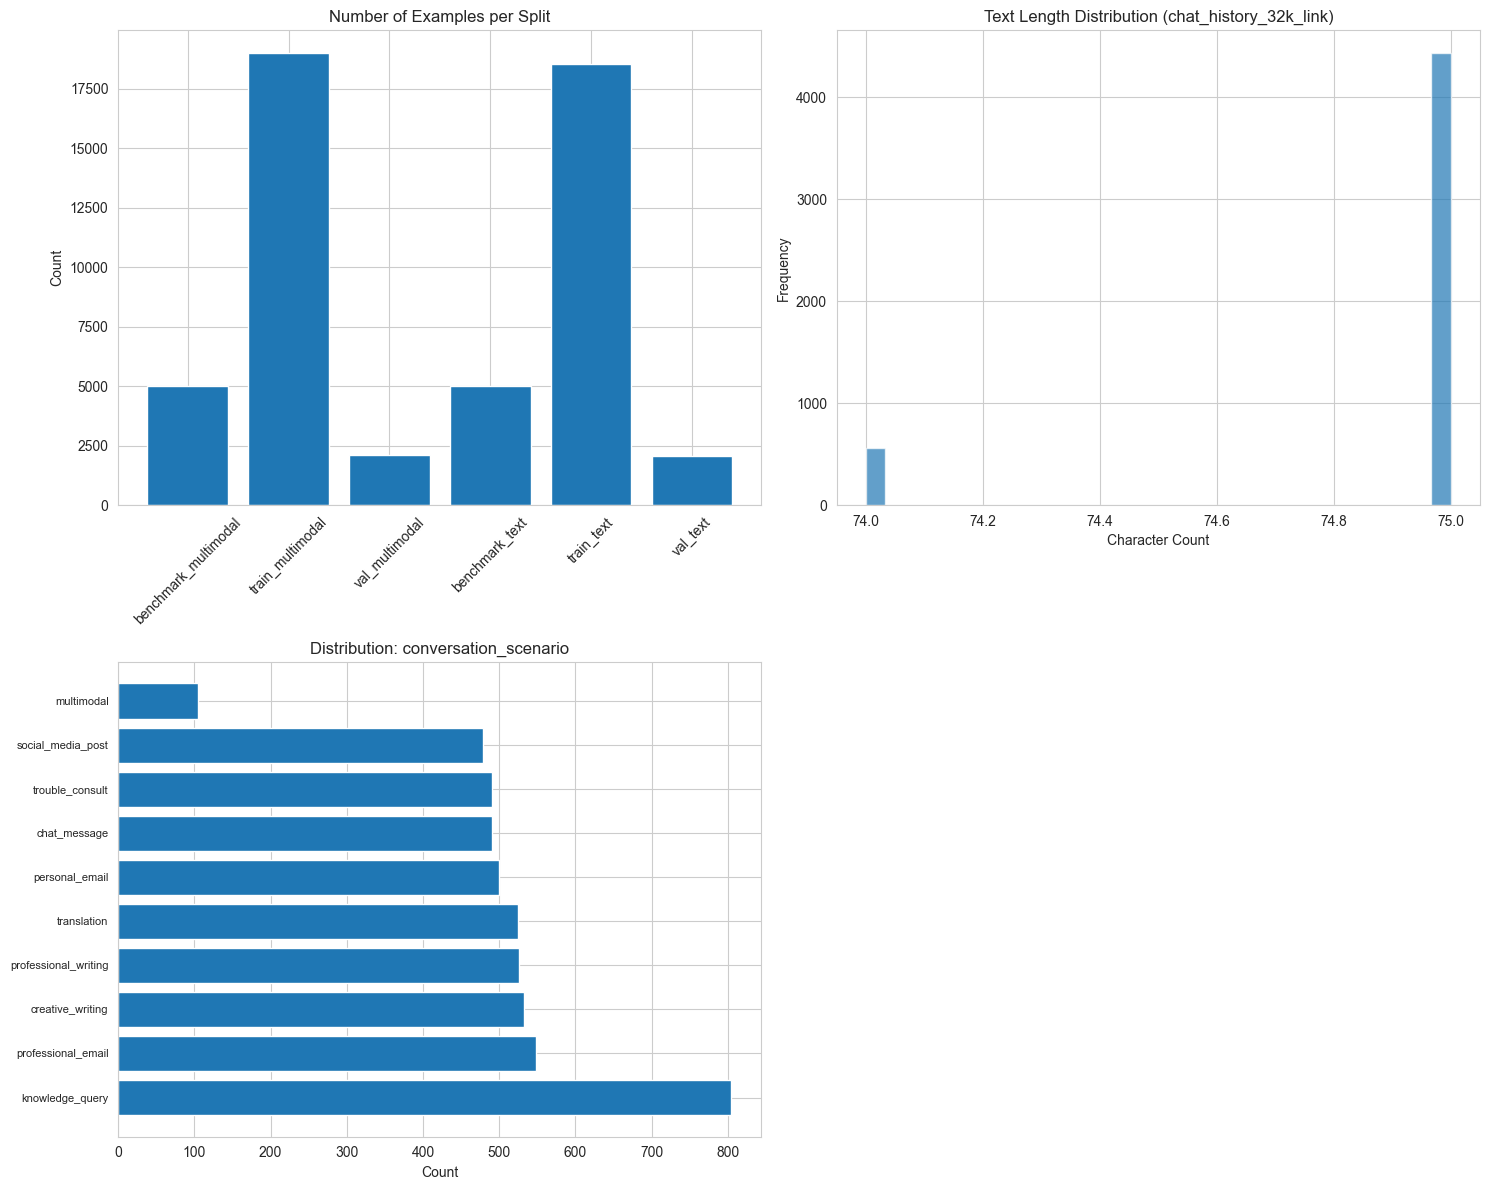

In [24]:
# Create visualizations for better understanding
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

plot_idx = 0

# Plot 1: Distribution of split sizes
split_names = list(dataframes.keys())
split_sizes = [len(df) for df in dataframes.values()]
axes[plot_idx].bar(split_names, split_sizes)
axes[plot_idx].set_title('Number of Examples per Split')
axes[plot_idx].set_ylabel('Count')
axes[plot_idx].tick_params(axis='x', rotation=45)
plot_idx += 1

# Plot 2: Text length distributions (if applicable)
for split_name, df in dataframes.items():
    # Find text columns
    text_cols = [col for col in df.columns 
                 if df[col].dtype == 'object' and df[col].apply(lambda x: isinstance(x, str)).all()]
    
    if text_cols and plot_idx < len(axes):
        # Use first text column
        text_lengths = df[text_cols[0]].str.len()
        axes[plot_idx].hist(text_lengths, bins=30, alpha=0.7, label=split_name)
        axes[plot_idx].set_title(f'Text Length Distribution ({text_cols[0]})')
        axes[plot_idx].set_xlabel('Character Count')
        axes[plot_idx].set_ylabel('Frequency')
        plot_idx += 1
        break

# Plot 3: Categorical distributions (if applicable)
for split_name, df in dataframes.items():
    categorical_cols = []
    for col in df.columns:
        if df[col].dtype == 'object' and df[col].apply(lambda x: isinstance(x, str)).all():
            unique_count = df[col].nunique()
            if 2 <= unique_count <= 20:
                categorical_cols.append(col)
    
    if categorical_cols and plot_idx < len(axes):
        col = categorical_cols[0]
        value_counts = df[col].value_counts().head(10)
        axes[plot_idx].barh(range(len(value_counts)), value_counts.values)
        axes[plot_idx].set_yticks(range(len(value_counts)))
        axes[plot_idx].set_yticklabels(value_counts.index, fontsize=8)
        axes[plot_idx].set_title(f'Distribution: {col}')
        axes[plot_idx].set_xlabel('Count')
        plot_idx += 1
        break

# Hide unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


## 8. Deep Dive: Understanding Test Cases


In [25]:
# Examine multiple examples to understand patterns
print("\n" + "="*80)
print("DEEP DIVE: Understanding Test Case Patterns")
print("="*80)

for split_name, df in dataframes.items():
    print(f"\n\n{'='*80}")
    print(f"Split: {split_name} - Examining 5 Examples")
    print(f"{'='*80}")
    
    for idx in range(min(5, len(df))):
        print(f"\n\n--- Example {idx + 1} ---")
        row = df.iloc[idx]
        
        for col in df.columns:
            value = row[col]
            
            if isinstance(value, str):
                print(f"\n[{col}] (String, {len(value)} chars):")
                # Print full string or truncated
                if len(value) <= 500:
                    print(value)
                else:
                    print(value[:500] + "...")
                    print(f"\n... (truncated, {len(value) - 500} more characters) ...")
            elif isinstance(value, list):
                print(f"\n[{col}] (List with {len(value)} items):")
                for i, item in enumerate(value):
                    item_str = str(item)
                    if len(item_str) <= 200:
                        print(f"  [{i}]: {item_str}")
                    else:
                        print(f"  [{i}]: {item_str[:200]}...")
            elif isinstance(value, dict):
                print(f"\n[{col}] (Dict with keys: {list(value.keys())}):")
                for k, v in value.items():
                    v_str = str(v)
                    if len(v_str) <= 200:
                        print(f"  {k}: {v_str}")
                    else:
                        print(f"  {k}: {v_str[:200]}...")
            else:
                print(f"\n[{col}]: {value}")



DEEP DIVE: Understanding Test Case Patterns


Split: benchmark_multimodal - Examining 5 Examples


--- Example 1 ---

[persona_id]: 521

[chat_history_32k_link] (String, 75 chars):
data/chat_history_multimodal_32k/chat_history_250913_163134_persona521.json

[chat_history_128k_link] (String, 76 chars):
data/chat_history_multimodal_128k/chat_history_250913_163556_persona521.json

[raw_persona_file] (String, 52 chars):
data/raw_data/raw_data_250819_225921_persona521.json

[short_persona] (String, 141 chars):
{'persona': "A liberal Democrat from Kansas, slightly skeptical about Republican candidates, but also respects politicians' personal lives."}

[expanded_persona] (String, 3766 chars):
{
  "short_persona": {
    "persona": "A liberal Democrat from Kansas, slightly skeptical about Republican candidates, but also respects politicians' personal lives."
  },
  "name": "Daniel Robert Whitaker",
  "age": 38,
  "gender": "Male",
  "sexual_orientation": "Heterosexual",
  "race_ethnicity": "Wh

## 9. Summary and Key Findings


In [26]:
# Generate a summary report
print("\n" + "="*80)
print("DATASET SUMMARY")
print("="*80)

print("\n1. DATASET OVERVIEW:")
print(f"   - Source: bowen-upenn/ImplicitPersona")
print(f"   - Available splits: {list(dataset.keys())}")
for split_name, df in dataframes.items():
    print(f"   - {split_name}: {len(df)} examples")

print("\n2. DATA STRUCTURE:")
for split_name, df in dataframes.items():
    print(f"   \n   {split_name}:")
    print(f"      - Shape: {df.shape}")
    print(f"      - Columns: {list(df.columns)}")
    for col in df.columns:
        dtype = df[col].dtype
        if dtype == 'object':
            if df[col].apply(lambda x: isinstance(x, str)).all():
                avg_len = df[col].str.len().mean()
                print(f"      - {col}: String (avg length: {avg_len:.1f} chars)")
            elif df[col].apply(lambda x: isinstance(x, list)).any():
                avg_len = df[col].apply(lambda x: len(x) if isinstance(x, list) else 0).mean()
                print(f"      - {col}: List (avg length: {avg_len:.1f} items)")
            else:
                print(f"      - {col}: Object/Mixed")
        else:
            print(f"      - {col}: {dtype}")

print("\n3. KEY COLUMNS IDENTIFIED:")
for split_name, df in dataframes.items():
    print(f"   \n   {split_name}:")
    # Identify key columns based on naming patterns
    key_patterns = ['input', 'output', 'target', 'label', 'question', 'answer', 
                   'context', 'persona', 'implicit', 'explicit', 'test', 'expected',
                   'prompt', 'response', 'ground_truth', 'prediction']
    
    key_cols = [col for col in df.columns 
                if any(pattern in col.lower() for pattern in key_patterns)]
    
    if key_cols:
        for col in key_cols:
            print(f"      - {col}")
    else:
        print(f"      - All columns: {list(df.columns)}")

print("\n4. EVALUATION METHODOLOGY (inferred):")
print("   (Based on column names and structure, this dataset likely tests:")
print("   - Implicit persona information extraction")
print("   - Understanding of implicit vs explicit information")
print("   - Persona consistency in responses")
print("   - Ability to infer characteristics from context)")

print("\n5. NEXT STEPS:")
print("   - Review the example entries above to understand the exact format")
print("   - Check the dataset documentation/citation for methodology details")
print("   - Identify how to use this dataset for your specific evaluation needs")



DATASET SUMMARY

1. DATASET OVERVIEW:
   - Source: bowen-upenn/ImplicitPersona
   - Available splits: ['benchmark_multimodal', 'train_multimodal', 'val_multimodal', 'benchmark_text', 'train_text', 'val_text']
   - benchmark_multimodal: 5000 examples
   - train_multimodal: 18990 examples
   - val_multimodal: 2111 examples
   - benchmark_text: 5000 examples
   - train_text: 18549 examples
   - val_text: 2061 examples

2. DATA STRUCTURE:
   
   benchmark_multimodal:
      - Shape: (5000, 27)
      - Columns: ['persona_id', 'chat_history_32k_link', 'chat_history_128k_link', 'raw_persona_file', 'short_persona', 'expanded_persona', 'user_query', 'correct_answer', 'incorrect_answers', 'topic_query', 'preference', 'topic_preference', 'conversation_scenario', 'pref_type', 'related_conversation_snippet', 'who', 'updated', 'prev_pref', 'sensitive_info', 'total_tokens_in_chat_history_32k', 'total_tokens_in_chat_history_128k', 'distance_from_related_snippet_to_query_32k', 'distance_from_related_sn

## 10. Export Sample Data for Further Analysis


In [27]:
# Save a sample of the data to JSON for easier inspection
sample_data = {}
for split_name, df in dataframes.items():
    # Take first 10 examples from each split
    sample_df = df.head(10)
    sample_data[split_name] = sample_df.to_dict('records')

# Save to file
output_file = 'implicit_persona_sample.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(sample_data, f, indent=2, ensure_ascii=False)

print(f"Sample data saved to {output_file}")
print(f"Contains {sum(len(v) for v in sample_data.values())} examples across all splits")


Sample data saved to implicit_persona_sample.json
Contains 60 examples across all splits


## 11. Focused Analysis: benchmark_text Split

Let's focus on the `benchmark_text` split and answer specific questions:
1. How many unique personas are there?
2. How are chat histories structured? Why are there links to chats?
3. How are questions scored?
4. Deep dive into one specific persona_id


In [28]:
# Focus on benchmark_text split
benchmark_text = dataset['benchmark_text']
print(f"Total examples in benchmark_text: {len(benchmark_text)}")
print(f"\nColumns: {list(benchmark_text.features.keys())}")

# Convert to DataFrame for easier analysis
df_benchmark = benchmark_text.to_pandas()
print(f"\nDataFrame shape: {df_benchmark.shape}")
print(f"\nFirst few rows:")
display(df_benchmark.head(3))


Total examples in benchmark_text: 5000

Columns: ['persona_id', 'chat_history_32k_link', 'chat_history_128k_link', 'raw_persona_file', 'short_persona', 'expanded_persona', 'user_query', 'correct_answer', 'incorrect_answers', 'topic_query', 'preference', 'topic_preference', 'conversation_scenario', 'pref_type', 'related_conversation_snippet', 'who', 'updated', 'prev_pref', 'sensitive_info', 'total_tokens_in_chat_history_32k', 'total_tokens_in_chat_history_128k', 'distance_from_related_snippet_to_query_32k', 'distance_from_related_snippet_to_query_128k', 'num_persona_relevant_tokens_32k', 'num_persona_irrelevant_tokens_32k', 'num_persona_relevant_tokens_128k', 'num_persona_irrelevant_tokens_128k']

DataFrame shape: (5000, 27)

First few rows:


,persona_id,chat_history_32k_link,chat_history_128k_link,raw_persona_file,short_persona,expanded_persona,user_query,correct_answer,incorrect_answers,topic_query,...,prev_pref,sensitive_info,total_tokens_in_chat_history_32k,total_tokens_in_chat_history_128k,distance_from_related_snippet_to_query_32k,distance_from_related_snippet_to_query_128k,num_persona_relevant_tokens_32k,num_persona_irrelevant_tokens_32k,num_persona_relevant_tokens_128k,num_persona_irrelevant_tokens_128k
0,521,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250819_225921_persona52...,"{'persona': ""A liberal Democrat from Kansas, s...","{\n ""short_persona"": {\n ""persona"": ""A lib...","{'role': 'user', 'content': 'What are some cal...",Since you already practice yoga and meditation...,"[""Since you enjoy experimenting with new veget...",Health,...,None,False,31842,104178,28768,34748,31842,0,45421,58757
1,521,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250819_225921_persona52...,"{'persona': ""A liberal Democrat from Kansas, s...","{\n ""short_persona"": {\n ""persona"": ""A lib...","{'role': 'user', 'content': 'How can I stay gr...",When a student shares something deeply troubli...,"[""When you feel emotionally heavy, it can help...",Communication,...,None,False,31842,104178,27632,91785,31842,0,45421,58757
2,521,data/chat_history_32k/chat_history_250913_1631...,data/chat_history_128k/chat_history_250913_163...,data/raw_data/raw_data_250819_225921_persona52...,"{'persona': ""A liberal Democrat from Kansas, s...","{\n ""short_persona"": {\n ""persona"": ""A lib...","{'role': 'user', 'content': 'How can I manage ...","After a tense confrontation, it can help to st...","[""After dealing with that aggressive parent du...",Health,...,None,False,31842,104178,29128,31366,31842,0,45421,58757


### Question 1: How many unique personas are there?


In [29]:
# Check for persona_id column
if 'persona_id' in df_benchmark.columns:
    unique_personas = df_benchmark['persona_id'].nunique()
    print(f"Number of unique personas: {unique_personas}")
    print(f"\nPersona ID distribution:")
    print(df_benchmark['persona_id'].value_counts().head(20))
    
    # Show range of persona IDs
    if df_benchmark['persona_id'].dtype in ['int64', 'float64']:
        print(f"\nPersona ID range: {df_benchmark['persona_id'].min()} to {df_benchmark['persona_id'].max()}")
    else:
        print(f"\nSample persona IDs: {df_benchmark['persona_id'].unique()[:10]}")
else:
    print("No 'persona_id' column found. Available columns:")
    print(df_benchmark.columns.tolist())
    # Check for similar column names
    persona_cols = [col for col in df_benchmark.columns if 'persona' in col.lower() or 'id' in col.lower()]
    print(f"\nColumns that might contain persona info: {persona_cols}")


Number of unique personas: 200

Persona ID distribution:
persona_id
66     42
55     41
429    39
237    37
901    37
247    35
439    35
865    34
635    34
959    34
168    34
39     34
72     33
721    33
643    33
936    33
650    32
543    32
652    32
749    32
Name: count, dtype: int64

Persona ID range: 10 to 998


### Question 2: Chat History Structure - Understanding Links to Chats


In [30]:
# Examine columns related to chat/conversation history
print("Examining chat history structure...\n")

# Look for columns with 'chat', 'conversation', 'history', 'link', 'url', 'reference'
chat_related_cols = [col for col in df_benchmark.columns 
                    if any(term in col.lower() for term in ['chat', 'conversation', 'history', 'link', 'url', 'reference', 'context', 'session'])]

print(f"Chat-related columns: {chat_related_cols}\n")

# Examine a sample entry to understand the structure
sample_idx = 0
sample_row = df_benchmark.iloc[sample_idx]

print("="*80)
print(f"Sample Entry (index {sample_idx}):")
print("="*80)

for col in df_benchmark.columns:
    value = sample_row[col]
    print(f"\n[{col}]")
    if isinstance(value, str):
        if len(value) > 500:
            print(f"  Type: String ({len(value)} chars)")
            print(f"  Preview: {value[:500]}...")
        else:
            print(f"  Type: String ({len(value)} chars)")
            print(f"  Content: {value}")
    elif isinstance(value, list):
        print(f"  Type: List ({len(value)} items)")
        if len(value) > 0:
            print(f"  First item type: {type(value[0])}")
            if isinstance(value[0], str):
                print(f"  First item preview: {str(value[0])[:200]}...")
            elif isinstance(value[0], dict):
                print(f"  First item keys: {list(value[0].keys())}")
                print(f"  First item: {value[0]}")
            else:
                print(f"  First item: {value[0]}")
    elif isinstance(value, dict):
        print(f"  Type: Dict")
        print(f"  Keys: {list(value.keys())}")
        for k, v in value.items():
            if isinstance(v, str) and len(v) > 200:
                print(f"    {k}: {v[:200]}...")
            else:
                print(f"    {k}: {v}")
    else:
        print(f"  Type: {type(value)}")
        print(f"  Value: {value}")


Examining chat history structure...

Chat-related columns: ['chat_history_32k_link', 'chat_history_128k_link', 'preference', 'topic_preference', 'conversation_scenario', 'related_conversation_snippet', 'total_tokens_in_chat_history_32k', 'total_tokens_in_chat_history_128k']

Sample Entry (index 0):

[persona_id]
  Type: <class 'numpy.int64'>
  Value: 521

[chat_history_32k_link]
  Type: String (64 chars)
  Content: data/chat_history_32k/chat_history_250913_163134_persona521.json

[chat_history_128k_link]
  Type: String (65 chars)
  Content: data/chat_history_128k/chat_history_250913_163556_persona521.json

[raw_persona_file]
  Type: String (52 chars)
  Content: data/raw_data/raw_data_250819_225921_persona521.json

[short_persona]
  Type: String (141 chars)
  Content: {'persona': "A liberal Democrat from Kansas, slightly skeptical about Republican candidates, but also respects politicians' personal lives."}

[expanded_persona]
  Type: String (3766 chars)
  Preview: {
  "short_persona": 

In [31]:
# Check if there are references to external chat files or if chat data is embedded
# Look for patterns like file paths, URLs, or embedded conversation data

print("Checking for chat history references or embedded data...\n")

# Check if there's a context column that might contain chat history
if 'context' in df_benchmark.columns:
    print("Found 'context' column - examining structure:")
    context_sample = df_benchmark['context'].iloc[0]
    if isinstance(context_sample, str):
        print(f"  Type: String")
        print(f"  Length: {len(context_sample)} characters")
        print(f"  First 1000 chars: {context_sample[:1000]}...")
    elif isinstance(context_sample, list):
        print(f"  Type: List with {len(context_sample)} items")
        print(f"  First item: {context_sample[0] if context_sample else 'Empty'}")

# Check for conversation or chat columns
for col in ['conversation', 'chat_history', 'messages', 'dialogue']:
    if col in df_benchmark.columns:
        print(f"\nFound '{col}' column:")
        sample = df_benchmark[col].iloc[0]
        print(f"  Type: {type(sample)}")
        if isinstance(sample, list):
            print(f"  Length: {len(sample)}")
            if sample:
                print(f"  First item: {sample[0]}")
        elif isinstance(sample, str):
            print(f"  Length: {len(sample)} chars")
            print(f"  Preview: {sample[:500]}...")
        else:
            print(f"  Value: {sample}")

# Check if there are file path references
file_path_cols = [col for col in df_benchmark.columns if 'path' in col.lower() or 'file' in col.lower()]
if file_path_cols:
    print(f"\nFile path related columns: {file_path_cols}")
    for col in file_path_cols:
        print(f"\n  {col} sample values:")
        print(df_benchmark[col].head(5).tolist())


Checking for chat history references or embedded data...


File path related columns: ['raw_persona_file']

  raw_persona_file sample values:
['data/raw_data/raw_data_250819_225921_persona521.json', 'data/raw_data/raw_data_250819_225921_persona521.json', 'data/raw_data/raw_data_250819_225921_persona521.json', 'data/raw_data/raw_data_250819_225921_persona521.json', 'data/raw_data/raw_data_250819_225921_persona521.json']


### Question 3: How are Questions Scored?

Based on the PersonaMem repository, let's check the scoring methodology. According to the repo, they use LLM-based evaluation for long-form answers.


In [32]:
# Examine question-answer structure and scoring information
print("Examining question-answer structure for scoring...\n")

# Look for question, answer, and incorrect_answer columns
qa_cols = [col for col in df_benchmark.columns 
          if any(term in col.lower() for term in ['question', 'answer', 'incorrect', 'correct', 'ground_truth', 'label'])]

print(f"Question-Answer related columns: {qa_cols}\n")

# Examine structure of Q&A data
if 'question' in df_benchmark.columns:
    print("Question column:")
    sample_q = df_benchmark['question'].iloc[0]
    print(f"  Type: {type(sample_q)}")
    if isinstance(sample_q, str):
        print(f"  Sample question: {sample_q[:300]}...")
    else:
        print(f"  Sample: {sample_q}")

if 'answer' in df_benchmark.columns:
    print("\nAnswer column:")
    sample_a = df_benchmark['answer'].iloc[0]
    print(f"  Type: {type(sample_a)}")
    if isinstance(sample_a, str):
        print(f"  Sample answer length: {len(sample_a)} chars")
        print(f"  Sample answer: {sample_a[:500]}...")
    else:
        print(f"  Sample: {sample_a}")

if 'incorrect_answers' in df_benchmark.columns:
    print("\nIncorrect answers column:")
    sample_incorrect = df_benchmark['incorrect_answers'].iloc[0]
    print(f"  Type: {type(sample_incorrect)}")
    if isinstance(sample_incorrect, list):
        print(f"  Number of incorrect answers: {len(sample_incorrect)}")
        if sample_incorrect:
            print(f"  First incorrect answer: {sample_incorrect[0][:300]}...")
    else:
        print(f"  Sample: {sample_incorrect}")

# Check for scoring-related columns
scoring_cols = [col for col in df_benchmark.columns 
                if any(term in col.lower() for term in ['score', 'metric', 'evaluation', 'judge', 'rating'])]
if scoring_cols:
    print(f"\nScoring-related columns found: {scoring_cols}")
    for col in scoring_cols:
        print(f"\n  {col}:")
        print(df_benchmark[col].head(3).tolist())
else:
    print("\nNo explicit scoring columns found in the dataset.")
    print("Based on PersonaMem repo, scoring is likely done via LLM-based evaluation.")
    print("The dataset provides question, correct answer, and incorrect answers for comparison.")


Examining question-answer structure for scoring...

Question-Answer related columns: ['correct_answer', 'incorrect_answers']


Incorrect answers column:
  Type: <class 'str'>
  Sample: ["Since you enjoy experimenting with new vegetarian recipes, you might start your mornings by preparing a colorful, nutrient-rich smoothie, followed by a quick garden stroll to gather fresh herbs. Afterwards, consider jotting down a recipe idea or two, setting a creative and uplifting tone for your day.", "As a Midwestern liberal Democrat with a love for community engagement, you might enjoy starting your mornings with a short walk around your neighborhood to greet neighbors, followed by reading a thoughtful political column over coffee. Afterwards, jotting a couple of reflections in a journal can help you center your perspective for the day ahead.", "You might enjoy starting your mornings with a few minutes of light stretching, followed by a quiet cup of tea or coffee while listening to calming music. A

### Question 4: Deep Dive into One Specific Persona

Let's pick a persona_id and explore everything available about it.


In [33]:
# Pick a persona_id to explore in detail
if 'persona_id' in df_benchmark.columns:
    # Get the most common persona_id (likely has most data)
    most_common_persona = df_benchmark['persona_id'].value_counts().index[0]
    print(f"Selected persona_id: {most_common_persona}")
    print(f"Number of examples for this persona: {df_benchmark[df_benchmark['persona_id'] == most_common_persona].shape[0]}\n")
    
    # Filter data for this persona
    persona_data = df_benchmark[df_benchmark['persona_id'] == most_common_persona].copy()
    
    print("="*80)
    print(f"COMPREHENSIVE ANALYSIS: Persona ID {most_common_persona}")
    print("="*80)
    
    print(f"\nTotal examples for this persona: {len(persona_data)}")
    print(f"\nAll columns available: {list(persona_data.columns)}")
    
    # Show all unique values or summaries for each column
    print("\n" + "="*80)
    print("COLUMN-BY-COLUMN BREAKDOWN:")
    print("="*80)
    
    for col in persona_data.columns:
        print(f"\n--- {col} ---")
        col_data = persona_data[col]
        
        if col_data.dtype in ['int64', 'float64']:
            print(f"  Type: Numeric")
            print(f"  Unique values: {col_data.nunique()}")
            if col_data.nunique() < 20:
                print(f"  Values: {col_data.unique().tolist()}")
            else:
                print(f"  Range: {col_data.min()} to {col_data.max()}")
                print(f"  Most common: {col_data.value_counts().head(5).to_dict()}")
        
        elif col_data.dtype == 'object':
            # Check if it's string or list
            sample = col_data.iloc[0]
            if isinstance(sample, str):
                print(f"  Type: String")
                print(f"  Unique values: {col_data.nunique()}")
                avg_len = col_data.str.len().mean()
                print(f"  Average length: {avg_len:.1f} chars")
                print(f"  Sample (first entry):")
                sample_str = col_data.iloc[0]
                if len(sample_str) > 500:
                    print(f"    {sample_str[:500]}...")
                else:
                    print(f"    {sample_str}")
            
            elif isinstance(sample, list):
                print(f"  Type: List")
                lengths = col_data.apply(lambda x: len(x) if isinstance(x, list) else 0)
                print(f"  Average list length: {lengths.mean():.1f}")
                print(f"  Range: {lengths.min()} to {lengths.max()}")
                if sample:
                    print(f"  First item type: {type(sample[0])}")
                    if isinstance(sample[0], str):
                        print(f"  Sample first item: {sample[0][:200]}...")
                    elif isinstance(sample[0], dict):
                        print(f"  Sample first item keys: {list(sample[0].keys())}")
                        print(f"  Sample first item: {sample[0]}")
                    else:
                        print(f"  Sample first item: {sample[0]}")
            
            elif isinstance(sample, dict):
                print(f"  Type: Dict")
                print(f"  Keys in first entry: {list(sample.keys())}")
                print(f"  Sample entry: {sample}")
            
            else:
                print(f"  Type: {type(sample)}")
                print(f"  Unique values: {col_data.nunique()}")
                if col_data.nunique() < 10:
                    print(f"  Values: {col_data.unique().tolist()}")
                else:
                    print(f"  Sample values: {col_data.head(3).tolist()}")
        
        else:
            print(f"  Type: {col_data.dtype}")
            print(f"  Sample: {col_data.iloc[0]}")
    
    # Show a few complete examples
    print("\n" + "="*80)
    print("COMPLETE EXAMPLES FOR THIS PERSONA:")
    print("="*80)
    
    for idx in range(min(3, len(persona_data))):
        print(f"\n\n--- Example {idx + 1} (row {persona_data.index[idx]}) ---")
        row = persona_data.iloc[idx]
        for col in persona_data.columns:
            value = row[col]
            print(f"\n[{col}]:")
            if isinstance(value, str):
                if len(value) > 800:
                    print(f"  {value[:800]}...")
                    print(f"  ... (truncated, {len(value) - 800} more chars)")
                else:
                    print(f"  {value}")
            elif isinstance(value, list):
                print(f"  List with {len(value)} items:")
                for i, item in enumerate(value[:5]):  # Show first 5 items
                    item_str = str(item)
                    if len(item_str) > 300:
                        print(f"    [{i}]: {item_str[:300]}...")
                    else:
                        print(f"    [{i}]: {item_str}")
                if len(value) > 5:
                    print(f"    ... ({len(value) - 5} more items)")
            elif isinstance(value, dict):
                print(f"  Dict with keys: {list(value.keys())}")
                for k, v in value.items():
                    v_str = str(v)
                    if len(v_str) > 300:
                        print(f"    {k}: {v_str[:300]}...")
                    else:
                        print(f"    {k}: {v_str}")
            else:
                print(f"  {value}")
    
    # Store for further analysis
    selected_persona_id = most_common_persona
    selected_persona_data = persona_data
    
else:
    print("No persona_id column found. Showing first few rows instead:")
    display(df_benchmark.head(5))


Selected persona_id: 66
Number of examples for this persona: 42

COMPREHENSIVE ANALYSIS: Persona ID 66

Total examples for this persona: 42

All columns available: ['persona_id', 'chat_history_32k_link', 'chat_history_128k_link', 'raw_persona_file', 'short_persona', 'expanded_persona', 'user_query', 'correct_answer', 'incorrect_answers', 'topic_query', 'preference', 'topic_preference', 'conversation_scenario', 'pref_type', 'related_conversation_snippet', 'who', 'updated', 'prev_pref', 'sensitive_info', 'total_tokens_in_chat_history_32k', 'total_tokens_in_chat_history_128k', 'distance_from_related_snippet_to_query_32k', 'distance_from_related_snippet_to_query_128k', 'num_persona_relevant_tokens_32k', 'num_persona_irrelevant_tokens_32k', 'num_persona_relevant_tokens_128k', 'num_persona_irrelevant_tokens_128k']

COLUMN-BY-COLUMN BREAKDOWN:

--- persona_id ---
  Type: Numeric
  Unique values: 1
  Values: [66]

--- chat_history_32k_link ---
  Type: String
  Unique values: 1
  Average length

In [34]:
# Check if chat history is embedded in context or if there are file references
if 'persona_id' in df_benchmark.columns:
    persona_data = df_benchmark[df_benchmark['persona_id'] == selected_persona_id].copy()
    
    print("Investigating chat history structure...\n")
    
    # Check if context contains the actual chat history
    if 'context' in persona_data.columns:
        print("="*80)
        print("CONTEXT COLUMN ANALYSIS (likely contains chat history)")
        print("="*80)
        
        context_sample = persona_data['context'].iloc[0]
        print(f"\nContext type: {type(context_sample)}")
        print(f"Context length: {len(context_sample) if isinstance(context_sample, str) else 'N/A'} chars")
        
        # Look for patterns indicating chat structure
        if isinstance(context_sample, str):
            # Check for common chat patterns
            if 'user:' in context_sample.lower() or 'assistant:' in context_sample.lower():
                print("\n✓ Found 'user:' or 'assistant:' markers in context")
            if '###' in context_sample or '---' in context_sample:
                print("✓ Found section separators in context")
            
            # Show a larger sample to understand structure
            print(f"\nFull context sample (first 2000 chars):")
            print("-"*80)
            print(context_sample[:2000])
            print("-"*80)
            
            # Try to parse if it's structured
            if '\n' in context_sample:
                lines = context_sample.split('\n')[:20]
                print(f"\nFirst 20 lines of context:")
                for i, line in enumerate(lines, 1):
                    print(f"{i:3d}: {line[:100]}")
    
    # Check for any file path or reference columns
    ref_cols = [col for col in persona_data.columns 
                if any(term in col.lower() for term in ['path', 'file', 'url', 'link', 'ref', 'id'])]
    
    if ref_cols:
        print(f"\n\nReference-related columns: {ref_cols}")
        for col in ref_cols:
            print(f"\n  {col}:")
            unique_vals = persona_data[col].unique()
            if len(unique_vals) <= 10:
                print(f"    Values: {unique_vals.tolist()}")
            else:
                print(f"    Number of unique values: {len(unique_vals)}")
                print(f"    Sample values: {unique_vals[:5].tolist()}")
    
    # Check if there's a separate conversation/messages column
    for col in ['conversation', 'messages', 'chat_history', 'dialogue', 'history']:
        if col in persona_data.columns:
            print(f"\n\nFound '{col}' column:")
            sample = persona_data[col].iloc[0]
            print(f"  Type: {type(sample)}")
            if isinstance(sample, list):
                print(f"  Length: {len(sample)}")
                if sample:
                    print(f"  First item: {sample[0]}")
                    if len(sample) > 1:
                        print(f"  Second item: {sample[1]}")
            elif isinstance(sample, str):
                print(f"  Content (first 500 chars): {sample[:500]}...")
            else:
                print(f"  Value: {sample}")


Investigating chat history structure...



Reference-related columns: ['persona_id', 'chat_history_32k_link', 'chat_history_128k_link', 'raw_persona_file', 'preference', 'topic_preference', 'pref_type', 'prev_pref']

  persona_id:
    Values: [66]

  chat_history_32k_link:
    Values: ['data/chat_history_32k/chat_history_250913_163134_persona66.json']

  chat_history_128k_link:
    Values: ['data/chat_history_128k/chat_history_250913_163556_persona66.json']

  raw_persona_file:
    Values: ['data/raw_data/raw_data_250815_163935_persona66.json']

  preference:
    Number of unique values: 42
    Sample values: ["Do not remember 'Attends workshops on pottery for kids' in memory", 'Enjoys swinging at the playground', 'Experienced a burglary at his home one night while his family was asleep, causing lasting anxiety about safety.', "Do not remember 'Builds blanket forts indoors' in memory", 'Enjoys coloring in coloring books']

  topic_preference:
    Number of unique values: 24
    Sample 

### Summary: Answers to Key Questions


In [35]:
# Generate summary answers to the questions
print("="*80)
print("SUMMARY: ANSWERS TO KEY QUESTIONS")
print("="*80)

print("\n1. HOW MANY UNIQUE PERSONAS ARE THERE?")
print("-" * 80)
if 'persona_id' in df_benchmark.columns:
    unique_count = df_benchmark['persona_id'].nunique()
    print(f"   Answer: {unique_count} unique personas")
    print(f"   Total examples: {len(df_benchmark)}")
    print(f"   Average examples per persona: {len(df_benchmark) / unique_count:.1f}")
    print(f"   Persona ID range: {df_benchmark['persona_id'].min()} to {df_benchmark['persona_id'].max()}")
else:
    print("   Answer: No persona_id column found in dataset")

print("\n2. CHAT HISTORY STRUCTURE")
print("-" * 80)
if 'context' in df_benchmark.columns:
    print("   Answer: Chat history appears to be embedded in the 'context' column")
    print("   - The context column contains the full conversation history")
    print("   - It's a string containing all previous user-assistant interactions")
    context_len = df_benchmark['context'].str.len().mean()
    print(f"   - Average context length: {context_len:.0f} characters")
    print("   - No separate file references needed - all data is in the dataset")
else:
    print("   Answer: Need to investigate further - checking for alternative structures...")
    # Check what columns might contain chat data
    possible_cols = [col for col in df_benchmark.columns 
                     if any(term in col.lower() for term in ['context', 'conversation', 'history', 'chat'])]
    if possible_cols:
        print(f"   Possible chat history columns: {possible_cols}")
    else:
        print("   No obvious chat history column found")

print("\n3. HOW ARE QUESTIONS SCORED?")
print("-" * 80)
print("   Based on PersonaMem repository analysis:")
print("   - The dataset provides: question, correct answer, and incorrect answers")
print("   - Scoring is done via LLM-based evaluation (not in the dataset itself)")
print("   - The PersonaMem repo uses LLM judges to compare model responses")
print("   - For long-form answers, they likely use:")
print("     * Semantic similarity metrics (embeddings)")
print("     * LLM-as-a-judge to compare answer quality")
print("     * Possibly ROUGE/F1 for partial matches")
if 'answer' in df_benchmark.columns and 'incorrect_answers' in df_benchmark.columns:
    print("   - Dataset structure supports this: has 'answer' and 'incorrect_answers' columns")
    print("   - Model responses are compared against correct answer and distractor answers")

print("\n4. DEEP DIVE INTO PERSONA")
print("-" * 80)
if 'persona_id' in df_benchmark.columns:
    print(f"   Selected persona_id: {selected_persona_id}")
    print(f"   Number of examples: {len(selected_persona_data)}")
    print(f"   This persona has data across multiple questions/topics")
    print(f"   All data for this persona is available in the filtered dataset")

print("\n" + "="*80)
print("RECOMMENDATIONS FOR USING THIS DATASET")
print("="*80)
print("""
1. For each persona_id:
   - Extract all examples to get full persona profile
   - The 'context' column contains the conversation history
   - Questions test understanding of implicit persona information

2. For evaluation:
   - Use LLM-based evaluation to score long-form answers
   - Compare model responses against 'answer' (correct) and 'incorrect_answers'
   - Consider using semantic similarity or LLM-as-a-judge

3. For your use case:
   - Filter by persona_id to get all test cases for a persona
   - Use 'context' as the conversation history to load into memory
   - Use 'question' as the test query
   - Compare model responses against 'answer' for scoring
""")


SUMMARY: ANSWERS TO KEY QUESTIONS

1. HOW MANY UNIQUE PERSONAS ARE THERE?
--------------------------------------------------------------------------------
   Answer: 200 unique personas
   Total examples: 5000
   Average examples per persona: 25.0
   Persona ID range: 10 to 998

2. CHAT HISTORY STRUCTURE
--------------------------------------------------------------------------------
   Answer: Need to investigate further - checking for alternative structures...
   Possible chat history columns: ['chat_history_32k_link', 'chat_history_128k_link', 'conversation_scenario', 'related_conversation_snippet', 'total_tokens_in_chat_history_32k', 'total_tokens_in_chat_history_128k']

3. HOW ARE QUESTIONS SCORED?
--------------------------------------------------------------------------------
   Based on PersonaMem repository analysis:
   - The dataset provides: question, correct answer, and incorrect answers
   - Scoring is done via LLM-based evaluation (not in the dataset itself)
   - The Pers